In [9]:
import sys
import importlib
def reload_modules(*modules):
    for module in modules:
        if module.__name__ in sys.modules:
            importlib.reload(module)
        else:
            print(f"Module {module.__name__} is not currently imported.")
import matplotlib.pyplot as plt
import cv2
import imutils
from magpie_perception import pcd
from magpie_perception import utils
from magpie_perception.utils import label_wrist_image, find_object
from magpie_control import realsense_wrapper as real
from magpie_control import ur5
from magpie_control import gripper
reload_modules(pcd, utils, real, ur5, gripper)

In [1]:
import numpy as np
motion_plan = np.load("scalingforce/motion_plan.npy", allow_pickle=True).item()
motion_plan

goal_delta = np.array(motion_plan['position_goal'])
direction = np.array(motion_plan['position_direction'])
sign = np.where(direction < 0, -1, 1)
force = np.array(motion_plan['force']) * sign
wrench_goal = np.hstack((force, np.zeros(3)))
init_cmd = np.hstack((force / -300, np.zeros(3)))
duration = motion_plan['duration']
# duration = 5
grasp_force = motion_plan['grasp_force']
P = 0.0003 # stiffness gain, default is 0.0005


In [3]:
# # load everything
gripper_log = np.load("scalingforce/gripper_log.npy", allow_pickle=True).item()
robot_log   = np.load("scalingforce/robot_log.npy",   allow_pickle=True).item()
wrist_log   = np.load("scalingforce/wrist_log.npy",   allow_pickle=True).item()
wkspc_log   = np.load("scalingforce/wkspc_log.npy",   allow_pickle=True).item()

In [4]:
gripper_ts   = sorted(gripper_log.keys())
robot_ts   = sorted(robot_log.keys())
wrist_ts = sorted(wrist_log.keys())
wkspc_ts   = sorted(wkspc_log.keys())

In [5]:
from spatialmath.base import rodrigues, tr2rpy

# get first and last TCP pose of robot log
first_pose = np.array(robot_log[robot_ts[0]]['actual_TCP_pose'])
last_pose =  np.array(robot_log[robot_ts[-1]]['actual_TCP_pose'])
dist =  last_pose - first_pose
# get the rotation matrix from the wrist frame to the robot frame
rot = rodrigues(first_pose[3:6])
# transform distance to be relative to the first TCP wrist frame, use inverse of rot
dist_wrist = rot.T @ dist[:3]
dist_wrist

array([-0.072,  0.048, -0.003])

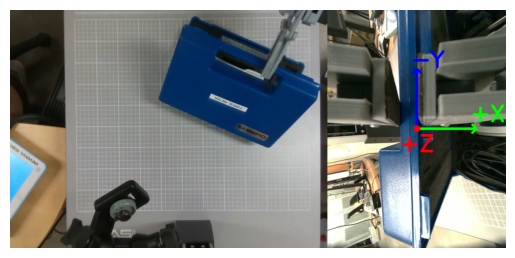

In [12]:
wrist_img_final = wrist_log[wrist_ts[-1]]['rgb']
wkspc_img_final = wkspc_log[wkspc_ts[-1]]['rgb']

wrist_final_rotated = cv2.rotate(wrist_img_final, cv2.ROTATE_90_COUNTERCLOCKWISE)
wrist_img_labeled = label_wrist_image(wrist_final_rotated.copy())
wkspc_final_resized = imutils.resize(wkspc_img_final, height=wrist_final_rotated.shape[0])
# final_img = np.hstack((img_wkspc_resized, wrist_img_labeled))
# final_img = np.hstack((img_wkspc_resized, wrist_img2_labeled))
final_img = np.hstack((wkspc_final_resized, wrist_img_labeled))
# cv2.imwrite(fn, cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(final_img)

In [32]:
goal_delta

array([0.1 , 0.05, 0.  ])